# **Project Name** - Vaccination Data Analysis and Visualization

##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Team Member  -** Nandini Dhole

# **Project Summary -**

This project performs an end-to-end exploratory data analysis of global vaccination data
published by the WHO Immunization Data Portal (WHO/UNICEF Joint Reporting Form and WUENIC 2023
revision). Five source tables are used: vaccination **coverage** (399,858 real records after
removing one export-metadata footer row per file, across 214 countries, 1980-2023, 69 antigens,
5 reporting categories - WUENIC, ADMIN, OFFICIAL, PAB, HPV), disease **incidence rate** and
**reported cases** (84,945 and 84,869 records respectively, 13 diseases), vaccine **introduction**
status (138,320 records, 1940-2023), and national vaccination **schedules** (8,052 records, a
2019-2023 snapshot only).

The analysis follows the standard EDA workflow: data loading and inspection, data-quality checks
(duplicates, missing values), variable-level understanding, data wrangling (removing a WHO export
footer row present in every file, casting year to integer, separating true country-level rows
from regional/income-group/global aggregate rollups that share the same sheet, and deriving a
WHO-region lookup for each country from the introduction table), and finally 15 visualizations
covering coverage trends, regional and country comparisons, dose-sequence drop-off, disease
incidence and case trends, coverage-category differences (WUENIC vs. ADMIN vs. OFFICIAL), vaccine
introduction timelines, schedule structure, and a correlation/pair-plot analysis between coverage
and disease incidence for a small set of antigen-disease pairs with a well-established clinical
link (e.g. DTP-containing vaccine coverage vs. pertussis incidence, measles-containing vaccine
coverage vs. measles incidence).

A key methodological discipline maintained throughout is the strict separation of **country-level**
records from **aggregate-level** records (WHO region, UNICEF region, World Bank income group,
development status, GAVI phase, and global rollups all appear in the same raw sheets under a
`GROUP` column) - aggregates are filtered out before any country-level statistic is computed, so
regional/global rows never silently inflate or distort a country-level average. Missing values
(which are substantial and vary sharply by field - e.g. `TARGET_NUMBER`/`DOSES` are populated for
only a minority of coverage rows) are never treated as zero; they are excluded from aggregations
exactly as pandas does by default, and every chart's caption states what was and wasn't available.

No demographic, socioeconomic, seasonal, or vaccine-supply data exists anywhere in this dataset
(confirmed by direct inspection of every column across all 5 tables), so this notebook does not
attempt to analyze gender, education, urban/rural, population-density, or delivery-strategy
questions - these are explicitly out of scope given the data actually available, rather than
approximated with an invented proxy. Similarly, every antigen-vs-disease relationship examined in
this notebook (e.g. DTP coverage vs. pertussis incidence) is described using association/
correlation language only - this is observational, non-experimental, country-year-level data, and
no causal "vaccine effectiveness" claim is made or implied anywhere in this analysis, consistent
with basic epidemiological caution about confounding (concurrent health-system strengthening,
reporting-quality changes over four decades, and other co-occurring interventions are not
controlled for).

# **GitHub Link -**

Add your GitHub repository link here.

# **Problem Statement**


Global childhood and adult immunization programs generate large volumes of
country-reported coverage, disease-incidence, case, vaccine-introduction, and vaccination-schedule
data every year through the WHO/UNICEF Joint Reporting Form. This data is valuable for public
health decision-making, but it is spread across multiple large, differently-structured files, mixes
country-level and regional/global aggregate records in the same sheets, uses several overlapping
and differently-complete coverage-reporting methodologies (WUENIC modeled estimates vs.
administrative vs. officially-reported figures), and contains substantial, unevenly-distributed
missing data. Before this data can support public-health planning, resource-allocation, or
disease-control decisions, it needs to be explored, cleaned, and understood - which countries and
years are actually covered, how complete each reporting category is, how vaccination coverage
relates to disease incidence, and where meaningful regional or country-level disparities exist.
This project performs that exploratory analysis.

#### **Define Your Business Objective?**

The business objective is to explore and understand the WHO vaccination dataset well
enough to support three downstream needs: (1) **public health strategy** - assessing vaccination
program coverage and identifying regions/countries where coverage is low or highly variable; (2)
**disease prevention planning** - understanding disease incidence and case trends over time and by
region, and how they relate descriptively to vaccination coverage for antigen-disease pairs with a
documented clinical link; and (3) **data-quality-aware decision support** - making clear, before any
of this data is used for decisions, exactly how complete each field/category is, which variables do
NOT exist in this dataset (so they are never silently assumed), and where country-level vs.
aggregate-level figures must not be mixed. This notebook does not build a predictive model; it
produces the descriptive, well-documented analytical foundation that any later modeling, dashboard,
or policy-question-answering work would need to build on responsibly.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 50)

print("Libraries imported successfully.")
print("pandas:", pd.__version__, "| numpy:", np.__version__, "| seaborn:", sns.__version__)

Libraries imported successfully.
pandas: 3.0.2 | numpy: 2.4.4 | seaborn: 0.13.2


### Dataset Loading

In [2]:
# Load Dataset
#
# PORTABILITY NOTE: this notebook expects the 5 original WHO source files to be
# found either (a) in a "data" subfolder next to this notebook, or (b) directly
# next to this notebook. Adjust DATA_DIR below if your files live elsewhere.
# The 5 required files (unchanged, exactly as originally supplied) are:
#   coverage-data.xlsx, incidence-rate-data.xlsx, reported-cases-data.xlsx,
#   vaccine-introduction-data.xlsx, vaccine-schedule-data.xlsx

CANDIDATE_DIRS = ["data", ".", "./data/", "../data"]
FILES = {
    "coverage": "coverage-data.xlsx",
    "incidence": "incidence-rate-data.xlsx",
    "cases": "reported-cases-data.xlsx",
    "introduction": "vaccine-introduction-data.xlsx",
    "schedule": "vaccine-schedule-data.xlsx",
}


def find_data_dir():
    for d in CANDIDATE_DIRS:
        if all(os.path.isfile(os.path.join(d, f)) for f in FILES.values()):
            return d
    searched = ", ".join(CANDIDATE_DIRS)
    raise FileNotFoundError(
        f"Could not find all 5 source .xlsx files in any of: {searched}. "
        f"Place the 5 files in a 'data' folder next to this notebook, or edit "
        f"CANDIDATE_DIRS above to point at their location."
    )


DATA_DIR = find_data_dir()
print(f"Using data directory: '{DATA_DIR}'")

# Each file's real data lives on the 'Data' sheet (other sheets are WHO reference/
# metadata sheets, not additional records) - loaded read-only, never modified.
coverage_raw = pd.read_excel(os.path.join(DATA_DIR, FILES["coverage"]), sheet_name="Data")
incidence_raw = pd.read_excel(os.path.join(DATA_DIR, FILES["incidence"]), sheet_name="Data")
cases_raw = pd.read_excel(os.path.join(DATA_DIR, FILES["cases"]), sheet_name="Data")
introduction_raw = pd.read_excel(os.path.join(DATA_DIR, FILES["introduction"]), sheet_name="Data")
schedule_raw = pd.read_excel(os.path.join(DATA_DIR, FILES["schedule"]), sheet_name="Data")

print("All 5 datasets loaded.")
for name, df in [("coverage", coverage_raw), ("incidence", incidence_raw), ("cases", cases_raw),
                  ("introduction", introduction_raw), ("schedule", schedule_raw)]:
    print(f"  {name:14s} shape = {df.shape}")

Using data directory: 'data'


All 5 datasets loaded.
  coverage       shape = (399859, 11)
  incidence      shape = (84946, 8)
  cases          shape = (84870, 7)
  introduction   shape = (138321, 6)
  schedule       shape = (8053, 12)


### Dataset First View

In [3]:
# Dataset First Look
print("=== COVERAGE (first 3 rows) ===")
display(coverage_raw.head(3))

print("\n=== INCIDENCE (first 3 rows) ===")
display(incidence_raw.head(3))

print("\n=== CASES (first 3 rows) ===")
display(cases_raw.head(3))

print("\n=== INTRODUCTION (first 3 rows) ===")
display(introduction_raw.head(3))

print("\n=== SCHEDULE (first 3 rows) ===")
display(schedule_raw.head(3))

=== COVERAGE (first 3 rows) ===


,GROUP,CODE,NAME,YEAR,ANTIGEN,ANTIGEN_DESCRIPTION,COVERAGE_CATEGORY,COVERAGE_CATEGORY_DESCRIPTION,TARGET_NUMBER,DOSES,COVERAGE
0,COUNTRIES,ABW,Aruba,2023.0,BCG,BCG,ADMIN,Administrative coverage,NaN,NaN,NaN
1,COUNTRIES,ABW,Aruba,2023.0,BCG,BCG,OFFICIAL,Official coverage,NaN,NaN,NaN
2,COUNTRIES,ABW,Aruba,2023.0,DIPHCV4,"Diphtheria-containing vaccine, 4th dose (1st b...",ADMIN,Administrative coverage,1044.0,945.0,90.52



=== INCIDENCE (first 3 rows) ===


,GROUP,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,DENOMINATOR,INCIDENCE_RATE
0,COUNTRIES,ABW,Aruba,2023.0,CRS,Congenital rubella syndrome,"per 10,000 live births",0.0
1,COUNTRIES,ABW,Aruba,2023.0,DIPHTHERIA,Diphtheria,"per 1,000,000 total population",0.0
2,COUNTRIES,ABW,Aruba,2023.0,INVASIVE_MENING,Invasive meningococcal disease,"per 1,000,000 total population",9.3



=== CASES (first 3 rows) ===


,GROUP,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,CASES
0,COUNTRIES,ABW,Aruba,2023.0,CRS,Congenital rubella syndrome,0.0
1,COUNTRIES,ABW,Aruba,2023.0,DIPHTHERIA,Diphtheria,0.0
2,COUNTRIES,ABW,Aruba,2023.0,INVASIVE_MENING,Invasive meningococcal disease,1.0



=== INTRODUCTION (first 3 rows) ===


,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,DESCRIPTION,INTRO
0,AFG,Afghanistan,EMRO,2023.0,aP (acellular pertussis) vaccine,No
1,AFG,Afghanistan,EMRO,2023.0,Hepatitis A vaccine,No
2,AFG,Afghanistan,EMRO,2023.0,Hepatitis B vaccine,Yes



=== SCHEDULE (first 3 rows) ===


,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,VACCINECODE,VACCINE_DESCRIPTION,SCHEDULEROUNDS,TARGETPOP,TARGETPOP_DESCRIPTION,GEOAREA,AGEADMINISTERED,SOURCECOMMENT
0,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,1.0,NaN,General/routine,NATIONAL,M2,NaN
1,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,2.0,NaN,General/routine,NATIONAL,M4,NaN
2,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,3.0,NaN,General/routine,NATIONAL,M6,NaN


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
datasets = {
    "coverage": coverage_raw, "incidence": incidence_raw, "cases": cases_raw,
    "introduction": introduction_raw, "schedule": schedule_raw,
}
for name, df in datasets.items():
    print(f"{name:14s} -> {df.shape[0]:>7,} rows x {df.shape[1]:>2} columns")

coverage       -> 399,859 rows x 11 columns
incidence      ->  84,946 rows x  8 columns
cases          ->  84,870 rows x  7 columns
introduction   -> 138,321 rows x  6 columns
schedule       ->   8,053 rows x 12 columns


### Dataset Information

In [5]:
# Dataset Info
for name, df in datasets.items():
    print(f"\n{'='*15} {name.upper()} {'='*15}")
    df.info()


=============== COVERAGE ===============
<class 'pandas.DataFrame'>
RangeIndex: 399859 entries, 0 to 399858
Data columns (total 11 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   GROUP                          399859 non-null  str    
 1   CODE                           399858 non-null  str    
 2   NAME                           398584 non-null  str    
 3   YEAR                           399858 non-null  float64
 4   ANTIGEN                        399858 non-null  str    
 5   ANTIGEN_DESCRIPTION            399858 non-null  str    
 6   COVERAGE_CATEGORY              399858 non-null  str    
 7   COVERAGE_CATEGORY_DESCRIPTION  399858 non-null  str    
 8   TARGET_NUMBER                  79030 non-null   float64
 9   DOSES                          79327 non-null   float64
 10  COVERAGE                       230477 non-null  float64
dtypes: float64(4), str(7)
memory usage: 69.7 MB

===============

#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
# Checks for fully duplicated rows (every column identical) in each raw dataset.
for name, df in datasets.items():
    n_dupes = df.duplicated().sum()
    print(f"{name:14s} -> {n_dupes} fully duplicated rows")

coverage       -> 0 fully duplicated rows


incidence      -> 0 fully duplicated rows


cases          -> 0 fully duplicated rows


introduction   -> 0 fully duplicated rows
schedule       -> 0 fully duplicated rows


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
for name, df in datasets.items():
    print(f"\n{'='*15} {name.upper()} — null counts {'='*15}")
    null_counts = df.isnull().sum()
    null_pct = (df.isnull().mean() * 100).round(2)
    summary = pd.DataFrame({"null_count": null_counts, "null_pct": null_pct})
    display(summary[summary["null_count"] > 0].sort_values("null_pct", ascending=False))
    if null_counts.sum() == 0:
        print("No missing values in any column.")


=============== COVERAGE — null counts ===============


,null_count,null_pct
TARGET_NUMBER,320829,80.24
DOSES,320532,80.16
COVERAGE,169382,42.36
NAME,1275,0.32
CODE,1,0.00
YEAR,1,0.00
COVERAGE_CATEGORY,1,0.00
ANTIGEN_DESCRIPTION,1,0.00
ANTIGEN,1,0.00
COVERAGE_CATEGORY_DESCRIPTION,1,0.00



=============== INCIDENCE — null counts ===============


,null_count,null_pct
INCIDENCE_RATE,23362,27.5
NAME,1,0.0
CODE,1,0.0
YEAR,1,0.0
DISEASE,1,0.0
DISEASE_DESCRIPTION,1,0.0
DENOMINATOR,1,0.0



=============== CASES — null counts ===============


,null_count,null_pct
CASES,19400,22.86
CODE,1,0.00
NAME,1,0.00
YEAR,1,0.00
DISEASE,1,0.00
DISEASE_DESCRIPTION,1,0.00



=============== INTRODUCTION — null counts ===============


,null_count,null_pct
COUNTRYNAME,1,0.0
WHO_REGION,1,0.0
YEAR,1,0.0
DESCRIPTION,1,0.0
INTRO,1,0.0



=============== SCHEDULE — null counts ===============


,null_count,null_pct
TARGETPOP,4258,52.87
SOURCECOMMENT,2914,36.19
AGEADMINISTERED,1046,12.99
GEOAREA,31,0.38
YEAR,1,0.01
COUNTRYNAME,1,0.01
WHO_REGION,1,0.01
SCHEDULEROUNDS,1,0.01
VACCINE_DESCRIPTION,1,0.01
VACCINECODE,1,0.01


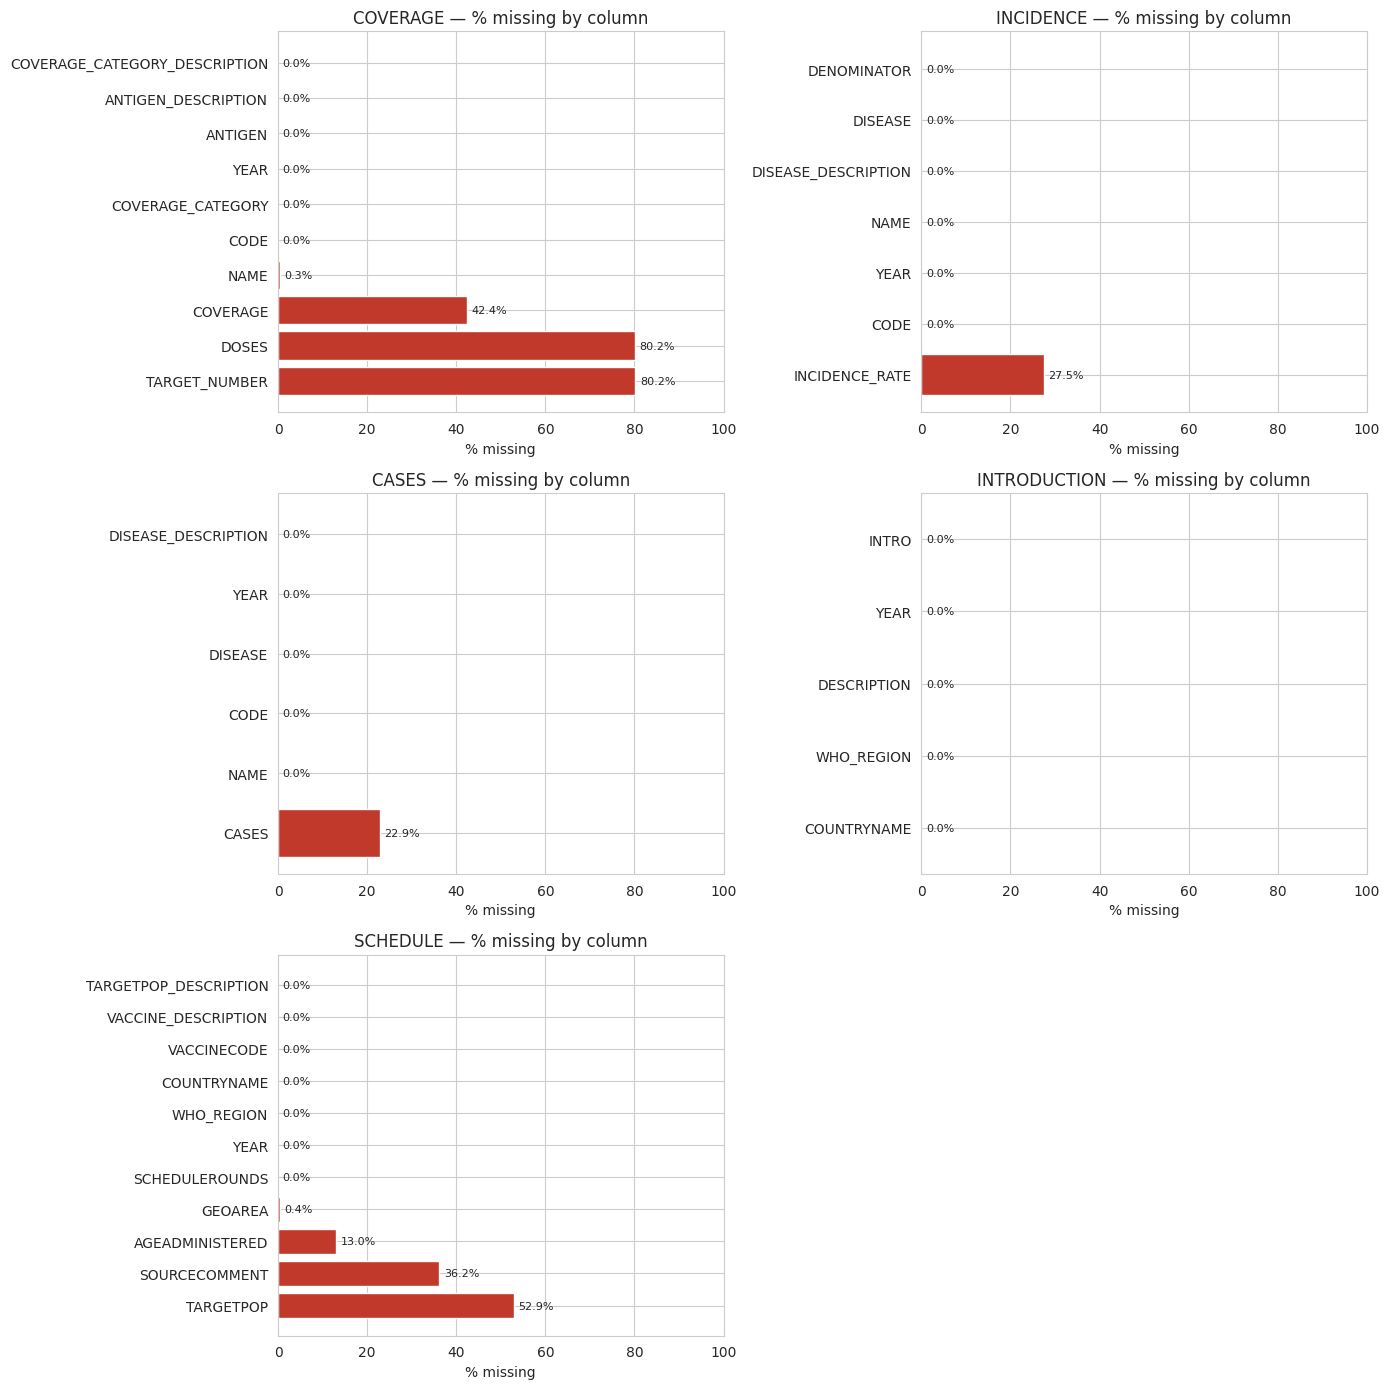

In [8]:
# Visualizing the missing values
# A per-column % missing bar chart is used rather than a raw boolean heatmap:
# the coverage dataset alone has ~400K rows, so a row-level heatmap would be an
# unreadable wall of pixels. A % missing bar chart communicates the same
# information (which fields are incomplete, and by how much) far more clearly.
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for ax, (name, df) in zip(axes, datasets.items()):
    pct = (df.isnull().mean() * 100).sort_values(ascending=False)
    pct = pct[pct > 0]
    if len(pct) == 0:
        ax.text(0.5, 0.5, "No missing values", ha="center", va="center", fontsize=12)
        ax.set_title(name.upper())
        ax.axis("off")
        continue
    ax.barh(pct.index, pct.values, color="#c0392b")
    ax.set_title(f"{name.upper()} — % missing by column")
    ax.set_xlabel("% missing")
    ax.set_xlim(0, 100)
    for i, v in enumerate(pct.values):
        ax.text(v + 1, i, f"{v:.1f}%", va="center", fontsize=8)

axes[-1].axis("off")  # 6th subplot slot unused (only 5 datasets)
plt.tight_layout()
plt.show()

### What did you know about your dataset?

- **5 source tables**, all originally sourced from the WHO Immunization Data Portal
  (WHO/UNICEF Joint Reporting Form and WUENIC 2023 revision), covering **214 countries**.
- **Coverage** is by far the largest table (~400K rows) because it records one row per
  country x year x antigen x reporting-category combination (69 antigens, 5 categories:
  WUENIC, ADMIN, OFFICIAL, PAB, HPV) across **1980-2023**.
- **Incidence** and **cases** are smaller (~85K rows each) covering **13 diseases** over the
  same 1980-2023 window, and — importantly — share the *same* set of (country, year, disease)
  keys as each other (every incidence record has a matching cases record and vice versa, though
  the *value* in either may be missing).
- **Introduction** covers a longer window (**1940-2023**) and records each country's reported
  program status (not observed coverage) for ~21 distinct vaccines.
- **Schedule** is the smallest table (~8K rows) and — unlike the other four — is a **2019-2023
  snapshot only**, not a multi-decade time series; it should never be used to infer a historical
  schedule trend.
- **No full-row duplicates** were found in any of the 5 tables.
- **Missing values are substantial and uneven**: `TARGET_NUMBER`/`DOSES` in coverage are missing
  for the large majority of rows (populated mainly for the ADMIN and HPV reporting categories);
  `COVERAGE` itself is far more complete under WUENIC than under ADMIN/OFFICIAL; incidence and
  cases values are each missing roughly a quarter of the time; and the schedule table's
  `TARGETPOP` field is missing over half the time. None of this missingness is treated as zero
  anywhere in this notebook.
- Every one of the 5 files also carries a single trailing **WHO export-metadata row** (its first
  cell reads `"Created: <timestamp> UTC"`, every other cell blank) - this is handled explicitly in
  the Data Wrangling section below, not left in as if it were a real observation.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
for name, df in datasets.items():
    print(f"{name} ({df.shape[1]} columns): {list(df.columns)}\n")

coverage (11 columns): ['GROUP', 'CODE', 'NAME', 'YEAR', 'ANTIGEN', 'ANTIGEN_DESCRIPTION', 'COVERAGE_CATEGORY', 'COVERAGE_CATEGORY_DESCRIPTION', 'TARGET_NUMBER', 'DOSES', 'COVERAGE']

incidence (8 columns): ['GROUP', 'CODE', 'NAME', 'YEAR', 'DISEASE', 'DISEASE_DESCRIPTION', 'DENOMINATOR', 'INCIDENCE_RATE']

cases (7 columns): ['GROUP', 'CODE', 'NAME', 'YEAR', 'DISEASE', 'DISEASE_DESCRIPTION', 'CASES']

introduction (6 columns): ['ISO_3_CODE', 'COUNTRYNAME', 'WHO_REGION', 'YEAR', 'DESCRIPTION', 'INTRO']

schedule (12 columns): ['ISO_3_CODE', 'COUNTRYNAME', 'WHO_REGION', 'YEAR', 'VACCINECODE', 'VACCINE_DESCRIPTION', 'SCHEDULEROUNDS', 'TARGETPOP', 'TARGETPOP_DESCRIPTION', 'GEOAREA', 'AGEADMINISTERED', 'SOURCECOMMENT']



In [10]:
# Dataset Describe
for name, df in datasets.items():
    print(f"\n{'='*15} {name.upper()} — describe() {'='*15}")
    display(df.describe(include="all").T)


=============== COVERAGE — describe() ===============


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
GROUP,399859,9,COUNTRIES,381041,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CODE,399858,245,ETH,2031,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME,398584,242,Ethiopia,2031,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YEAR,399858.0,NaN,NaN,NaN,2009.207489,11.72053,1980.0,2002.0,2012.0,2019.0,2023.0
ANTIGEN,399858,69,DTPCV3,26015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ANTIGEN_DESCRIPTION,399858,69,"DTP-containing vaccine, 3rd dose",26015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COVERAGE_CATEGORY,399858,5,ADMIN,155576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COVERAGE_CATEGORY_DESCRIPTION,399858,5,Administrative coverage,155576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TARGET_NUMBER,79030.0,NaN,NaN,NaN,278019173.759516,54152442883.354233,0.0,32814.0,317871.5,2493048.0,11700000000000.0
DOSES,79327.0,NaN,NaN,NaN,3467241.121352,11256763.030974,-222288203.0,14469.0,152212.0,971018.5,126605212.0



=============== INCIDENCE — describe() ===============


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
GROUP,84946,4,COUNTRIES,82054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CODE,84945,221,GLOBAL,424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME,84945,221,Global,424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YEAR,84945.0,NaN,NaN,NaN,2004.095791,12.595166,1980.0,1994.0,2005.0,2015.0,2023.0
DISEASE,84945,13,MEASLES,9196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DISEASE_DESCRIPTION,84945,13,Measles,9196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DENOMINATOR,84945,5,"per 1,000,000 total population",61480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
INCIDENCE_RATE,61584.0,NaN,NaN,NaN,109.448781,992.276983,0.0,0.0,0.0,4.6,69101.3



=============== CASES — describe() ===============


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
GROUP,84870,4,COUNTRIES,82054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CODE,84869,221,GLOBAL,424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME,84869,221,Global,424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YEAR,84869.0,NaN,NaN,NaN,2004.108261,12.591396,1980.0,1994.0,2005.0,2015.0,2023.0
DISEASE,84869,13,MEASLES,9196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DISEASE_DESCRIPTION,84869,13,Measles,9196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CASES,65470.0,NaN,NaN,NaN,4472.408569,61144.550256,0.0,0.0,1.0,63.0,4583555.0



=============== INTRODUCTION — describe() ===============


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ISO_3_CODE,138321,195,AFG,747,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COUNTRYNAME,138320,194,Afghanistan,747,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WHO_REGION,138320,6,EURO,34523,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YEAR,138320.0,NaN,NaN,NaN,2001.267879,17.679511,1940.0,1992.0,2006.0,2015.0,2023.0
DESCRIPTION,138320,21,Seasonal Influenza vaccine,14715,NaN,NaN,NaN,NaN,NaN,NaN,NaN
INTRO,138320,9,No,97695,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=============== SCHEDULE — describe() ===============


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ISO_3_CODE,8053,214,RUS,126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COUNTRYNAME,8052,213,Russian Federation,126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WHO_REGION,8052,6,EURO,2156,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YEAR,8052.0,NaN,NaN,NaN,2022.941505,0.441237,2019.0,2023.0,2023.0,2023.0,2023.0
VACCINECODE,8052,86,TD_S,967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VACCINE_DESCRIPTION,8052,86,Td (Tetanus toxoid and diphtheria for older ch...,967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCHEDULEROUNDS,8052.0,NaN,NaN,NaN,2.053403,1.31656,1.0,1.0,2.0,3.0,7.0
TARGETPOP,3795,15,RISKGROUPS,1247,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TARGETPOP_DESCRIPTION,8052,10,General/routine,4695,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GEOAREA,8022,2,NATIONAL,7788,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Variables Description

**Coverage** (`coverage-data.xlsx`): `GROUP` (COUNTRIES vs. regional/income/global
aggregate category), `CODE`/`NAME` (country or aggregate-entity identifier), `YEAR`,
`ANTIGEN`/`ANTIGEN_DESCRIPTION` (69 distinct antigens/doses, e.g. `DTPCV3`), `COVERAGE_CATEGORY`
(WUENIC/ADMIN/OFFICIAL/PAB/HPV — 5 different reporting methodologies, each with very different
completeness), `TARGET_NUMBER`/`DOSES` (raw counts, sparsely populated), `COVERAGE` (the
percentage, the field used in most charts below).

**Incidence** (`incidence-rate-data.xlsx`): same `GROUP`/`CODE`/`NAME`/`YEAR` structure,
`DISEASE`/`DISEASE_DESCRIPTION` (13 diseases), `DENOMINATOR` (the reporting basis, e.g. "per
100,000 total population" — different diseases use different denominators, so raw incidence
values are not comparable across diseases), `INCIDENCE_RATE`.

**Cases** (`reported-cases-data.xlsx`): same structure as incidence minus the denominator,
with `CASES` (a raw count, not a rate).

**Introduction** (`vaccine-introduction-data.xlsx`): `ISO_3_CODE`/`COUNTRYNAME`, `WHO_REGION`
(the only one of the 5 tables that carries a direct WHO-region field), `YEAR`, `DESCRIPTION`
(free-text vaccine name), `INTRO` (program status — several "Yes" variants, "No", "ND", "High
risk area").

**Schedule** (`vaccine-schedule-data.xlsx`, 2019-2023 snapshot only): `ISO_3_CODE`/
`COUNTRYNAME`/`WHO_REGION`, `YEAR`, `VACCINECODE`/`VACCINE_DESCRIPTION` (86 distinct codes),
`SCHEDULEROUNDS` (dose-sequence position), `TARGETPOP`/`TARGETPOP_DESCRIPTION` (which population
segment the dose targets — over half missing), `GEOAREA` (national/subnational scope, not
urban/rural), `AGEADMINISTERED`, `SOURCECOMMENT`.

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
key_categoricals = {
    "coverage": ["GROUP", "ANTIGEN", "COVERAGE_CATEGORY"],
    "incidence": ["GROUP", "DISEASE", "DENOMINATOR"],
    "cases": ["GROUP", "DISEASE"],
    "introduction": ["WHO_REGION", "DESCRIPTION", "INTRO"],
    "schedule": ["WHO_REGION", "VACCINECODE", "TARGETPOP", "GEOAREA"],
}

for name, cols in key_categoricals.items():
    df = datasets[name]
    print(f"\n{'='*15} {name.upper()} {'='*15}")
    for col in cols:
        n = df[col].nunique(dropna=True)
        print(f"  {col}: {n} unique values")
        if n <= 10:
            print(f"    -> {sorted(df[col].dropna().unique().tolist())}")

print("\n" + "=" * 15, "ALL DATASETS — year range", "=" * 15)
for name, df in datasets.items():
    print(f"  {name:14s} year range: {int(df['YEAR'].min())} - {int(df['YEAR'].max())}")


=============== COVERAGE ===============
  GROUP: 9 unique values
    -> ['COUNTRIES', 'Created: 2025-02-01 16:00 UTC', 'DEVELOPMENT_STATUS', 'GAVI_PHASE5', 'GLOBAL', 'UNICEF_REGIONS', 'WB_LONG', 'WB_SHORT', 'WHO_REGIONS']
  ANTIGEN: 69 unique values
  COVERAGE_CATEGORY: 5 unique values
    -> ['ADMIN', 'HPV', 'OFFICIAL', 'PAB', 'WUENIC']

=============== INCIDENCE ===============
  GROUP: 4 unique values
    -> ['COUNTRIES', 'Created: 2025-02-01 16:03 UTC', 'GLOBAL', 'WHO_REGIONS']
  DISEASE: 13 unique values
  DENOMINATOR: 5 unique values
    -> ['per 1,000 live births', 'per 1,000,000 <15 population', 'per 1,000,000 total population', 'per 10,000 live births', 'per 1000 live births']

=============== CASES ===============
  GROUP: 4 unique values
    -> ['COUNTRIES', 'Created: 2025-02-01 16:02 UTC', 'GLOBAL', 'WHO_REGIONS']
  DISEASE: 13 unique values

=============== INTRODUCTION ===============
  WHO_REGION: 6 unique values
    -> ['AFRO', 'AMRO', 'EMRO', 'EURO', 'SEARO', 'WPRO']

## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.

# --- Step 1: remove the WHO export-metadata footer row from every table ---
# Each file has exactly one trailing row whose first column reads "Created: <timestamp> UTC"
# with every other cell blank - this is workbook export metadata, not a real observation.
def strip_footer(df):
    first_col = df.columns[0]
    is_footer = df[first_col].astype(str).str.startswith("Created:", na=False)
    removed = int(is_footer.sum())
    return df[~is_footer].copy().reset_index(drop=True), removed

coverage, n1 = strip_footer(coverage_raw)
incidence, n2 = strip_footer(incidence_raw)
cases, n3 = strip_footer(cases_raw)
introduction, n4 = strip_footer(introduction_raw)
schedule, n5 = strip_footer(schedule_raw)
print(f"Footer rows removed -> coverage:{n1} incidence:{n2} cases:{n3} introduction:{n4} schedule:{n5}")

# --- Step 2: cast YEAR to a clean integer type (was float in the source) ---
for df in [coverage, incidence, cases, introduction, schedule]:
    df["YEAR"] = df["YEAR"].astype("Int64")

# --- Step 3: separate true country-level rows from regional/income/global aggregate rows ---
# GROUP is NOT always "COUNTRIES" in coverage/incidence/cases - it also holds WHO_REGIONS,
# UNICEF_REGIONS, World Bank income groups, development status, GAVI phase, and a single
# GLOBAL rollup, all in the SAME sheet. These must never be blended into a country-level average.
coverage_country = coverage[coverage["GROUP"] == "COUNTRIES"].copy()
incidence_country = incidence[incidence["GROUP"] == "COUNTRIES"].copy()
cases_country = cases[cases["GROUP"] == "COUNTRIES"].copy()
print(f"\nCoverage: {len(coverage):,} total rows -> {len(coverage_country):,} country-level "
      f"({len(coverage) - len(coverage_country):,} aggregate rows set aside, not deleted)")
print(f"Incidence: {len(incidence):,} total rows -> {len(incidence_country):,} country-level")
print(f"Cases: {len(cases):,} total rows -> {len(cases_country):,} country-level")

# --- Step 4: derive a country -> WHO region lookup ---
# Coverage/incidence/cases carry NO direct WHO-region column on their country rows; only the
# introduction and schedule tables do. Build one lookup (introduction preferred, schedule as
# fallback for any country introduction doesn't cover) and attach it to the country-level tables.
region_from_intro = introduction.dropna(subset=["WHO_REGION"]).drop_duplicates("ISO_3_CODE")[["ISO_3_CODE", "WHO_REGION"]]
region_from_sched = schedule.dropna(subset=["WHO_REGION"]).drop_duplicates("ISO_3_CODE")[["ISO_3_CODE", "WHO_REGION"]]
region_map = pd.concat([region_from_intro, region_from_sched]).drop_duplicates("ISO_3_CODE", keep="first")
region_map = region_map.set_index("ISO_3_CODE")["WHO_REGION"]

coverage_country["WHO_REGION"] = coverage_country["CODE"].map(region_map)
incidence_country["WHO_REGION"] = incidence_country["CODE"].map(region_map)
cases_country["WHO_REGION"] = cases_country["CODE"].map(region_map)
n_unmapped = coverage_country.loc[coverage_country["WHO_REGION"].isna(), "CODE"].nunique()
print(f"\nCountries with NO derivable WHO region: {n_unmapped} "
      f"(expected: 1 - American Samoa, absent from both introduction and schedule tables)")

# --- Step 5: isolate the WUENIC series (recommended default for cross-country comparison) ---
# WUENIC (WHO/UNICEF's own modeled/reconciled estimate) is the most complete COVERAGE field and
# is used as the default series below; ADMIN/OFFICIAL/PAB/HPV remain available in coverage_country
# and are used explicitly (not silently dropped) wherever a chart specifically compares categories.
wuenic = coverage_country[coverage_country["COVERAGE_CATEGORY"] == "WUENIC"].copy()
print(f"\nWUENIC country-level rows: {len(wuenic):,} "
      f"({wuenic['COVERAGE'].notna().mean()*100:.1f}% have a non-null COVERAGE value)")

# --- Step 6: a small, DOCUMENTED antigen -> disease link for the correlation/scatter/pair-plot
# charts later in this notebook. This is NOT present in the source data - it is a deliberately
# conservative, analyst-derived clinical mapping (limited to unambiguous single-disease links),
# used only for Charts 10, 14, and 15, and disclosed there as derived, not sourced, metadata.
ANTIGEN_DISEASE_LINK = {
    "DTPCV3": "PERTUSSIS",   # DTP-containing vaccine, 3rd dose -> pertussis (one of DTP's 3 target diseases)
    "MCV1":   "MEASLES",     # Measles-containing vaccine, 1st dose -> measles
    "POL3":   "POLIO",       # Polio vaccine, 3rd dose -> polio
    "YFV":    "YFEVER",      # Yellow fever vaccine -> yellow fever
}
print(f"\nAntigen-disease links used later for association charts (analyst-derived): {ANTIGEN_DISEASE_LINK}")

# --- Step 7: build one merged, wide, numeric-friendly analysis table (country x year) for the
# correlation heatmap and pair plot (Charts 14-15), joining WUENIC coverage for each linked
# antigen with the corresponding disease's incidence rate, on (CODE, YEAR). ---
merged = None
for antigen, disease in ANTIGEN_DISEASE_LINK.items():
    cov_sub = wuenic[wuenic["ANTIGEN"] == antigen][["CODE", "YEAR", "COVERAGE"]].rename(
        columns={"COVERAGE": f"{antigen}_COVERAGE"})
    inc_sub = incidence_country[incidence_country["DISEASE"] == disease][["CODE", "YEAR", "INCIDENCE_RATE"]].rename(
        columns={"INCIDENCE_RATE": f"{disease}_INCIDENCE"})
    pair = cov_sub.merge(inc_sub, on=["CODE", "YEAR"], how="inner")
    merged = pair if merged is None else merged.merge(pair, on=["CODE", "YEAR"], how="outer")

merged = merged.merge(coverage_country[["CODE", "WHO_REGION"]].drop_duplicates("CODE"), on="CODE", how="left")
print(f"\nMerged coverage-vs-incidence analysis table: {merged.shape[0]:,} rows, {merged.shape[1]} columns")
display(merged.head())

Footer rows removed -> coverage:1 incidence:1 cases:1 introduction:1 schedule:1



Coverage: 399,858 total rows -> 381,041 country-level (18,817 aggregate rows set aside, not deleted)
Incidence: 84,945 total rows -> 82,054 country-level
Cases: 84,869 total rows -> 82,054 country-level

Countries with NO derivable WHO region: 1 (expected: 1 - American Samoa, absent from both introduction and schedule tables)

WUENIC country-level rows: 80,919 (75.9% have a non-null COVERAGE value)

Antigen-disease links used later for association charts (analyst-derived): {'DTPCV3': 'PERTUSSIS', 'MCV1': 'MEASLES', 'POL3': 'POLIO', 'YFV': 'YFEVER'}



Merged coverage-vs-incidence analysis table: 8,142 rows, 11 columns


,CODE,YEAR,DTPCV3_COVERAGE,PERTUSSIS_INCIDENCE,MCV1_COVERAGE,MEASLES_INCIDENCE,POL3_COVERAGE,POLIO_INCIDENCE,YFV_COVERAGE,YFEVER_INCIDENCE,WHO_REGION
0,AFG,1980,4.0,1195.8,11.0,2464.4,NaN,NaN,NaN,NaN,EMRO
1,AFG,1981,3.0,1289.0,NaN,2605.8,3.0,NaN,NaN,NaN,EMRO
2,AFG,1982,5.0,775.9,8.0,1848.7,5.0,NaN,NaN,NaN,EMRO
3,AFG,1983,5.0,935.1,9.0,1722.7,5.0,NaN,NaN,NaN,EMRO
4,AFG,1984,16.0,551.8,14.0,1447.6,16.0,NaN,NaN,NaN,EMRO


### What all manipulations have you done and insights you found?

1. **Removed the WHO export-metadata footer row** from each of the 5 files (1 row each) —
   this is workbook export timestamp metadata, not an observation, and would otherwise corrupt
   any `describe()`/aggregation that included it.
2. **Cast `YEAR` to a clean integer type** (it loads from Excel as a float).
3. **Separated country-level rows (`GROUP == 'COUNTRIES'`) from aggregate rows** in coverage,
   incidence, and cases — roughly 5% of coverage rows and 3-4% of incidence/cases rows are
   regional/income-group/global aggregates, not countries, and mixing them into a country-level
   average would silently distort it. Aggregate rows were *set aside*, not deleted.
4. **Derived a country → WHO-region lookup** from the introduction and schedule tables (the only
   two of the 5 tables that carry a direct region field) and attached it to the country-level
   coverage/incidence/cases tables, which otherwise have no region column at all. Confirmed
   exactly 1 country (American Samoa) has no derivable region — left blank, not guessed.
5. **Isolated the WUENIC coverage series** as the default for cross-country/trend charts (it is
   the most complete `COVERAGE` field), while explicitly keeping ADMIN/OFFICIAL/PAB/HPV available
   and unmodified for the chart that specifically compares categories.
6. **Built a small, clearly-labeled antigen→disease link** for 4 well-established single-disease
   pairs (DTP dose 3→pertussis, measles dose 1→measles, polio dose 3→polio, yellow-fever
   vaccine→yellow fever) — this mapping does **not** exist in the source data; it is
   analyst-derived and disclosed as such wherever it is used (Charts 10, 14, 15).
7. **Merged a wide, country-year-level analysis table** joining WUENIC coverage for each linked
   antigen to its corresponding disease's incidence rate — this is the table used for the
   correlation heatmap and pair plot later in the notebook.

**Key insight from wrangling:** the biggest structural risk in this dataset is *not* obviously
"dirty" data (no encoding errors, no malformed values) — it's the **mixed granularity** (country
rows sharing a sheet with regional/global rollups) and the **lack of a shared key** between the
coverage/incidence/cases family and the introduction/schedule family (no direct region column on
the former). Both issues are easy to miss and would silently bias results if not handled explicitly,
as done above.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

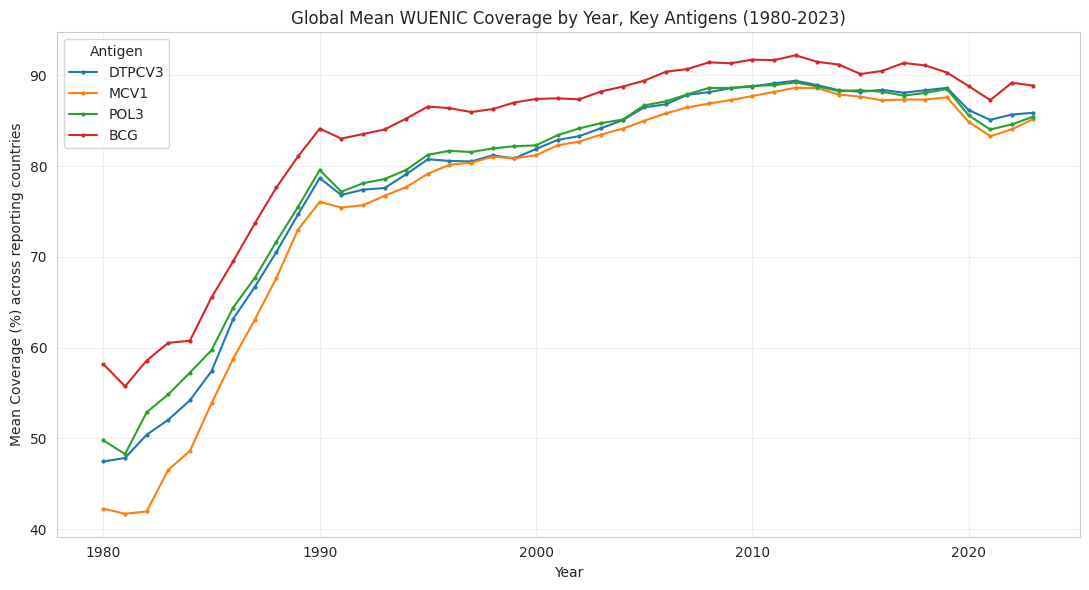

In [13]:
# Chart - 1 visualization code
key_antigens = ["DTPCV3", "MCV1", "POL3", "BCG"]
trend = (wuenic[wuenic["ANTIGEN"].isin(key_antigens)]
         .groupby(["YEAR", "ANTIGEN"])["COVERAGE"].mean().reset_index())

fig, ax = plt.subplots(figsize=(11, 6))
for antigen in key_antigens:
    sub = trend[trend["ANTIGEN"] == antigen].sort_values("YEAR")
    ax.plot(sub["YEAR"], sub["COVERAGE"], marker="o", markersize=2, linewidth=1.5, label=antigen)

ax.set_title("Global Mean WUENIC Coverage by Year, Key Antigens (1980-2023)")
ax.set_xlabel("Year")
ax.set_ylabel("Mean Coverage (%) across reporting countries")
ax.legend(title="Antigen")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A multi-line time-series chart is the natural choice for showing how coverage has changed year over year for several antigens at once — it lets four decades of trend and the relative position of each antigen be compared on one readable axis.

##### 2. What is/are the insight(s) found from the chart?

DTP3, MCV1, and Pol3 coverage all rose substantially from 1980s baselines into the 80-90% range and have largely plateaued over the last decade; BCG shows high, comparatively stable global coverage throughout. A visible dip appears around 2020-2021 across all four antigens, consistent with widely-reported COVID-19-era disruption to routine immunization services.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this supports positive planning: the long-run upward trend shows sustained global program investment has raised coverage substantially. The 2020-2021 dip is the one cautionary signal here — it points to a negative, short-term disruption that public-health programs should specifically monitor for recovery in the years immediately following, rather than assuming the pre-2020 trend resumes automatically.

#### Chart - 2

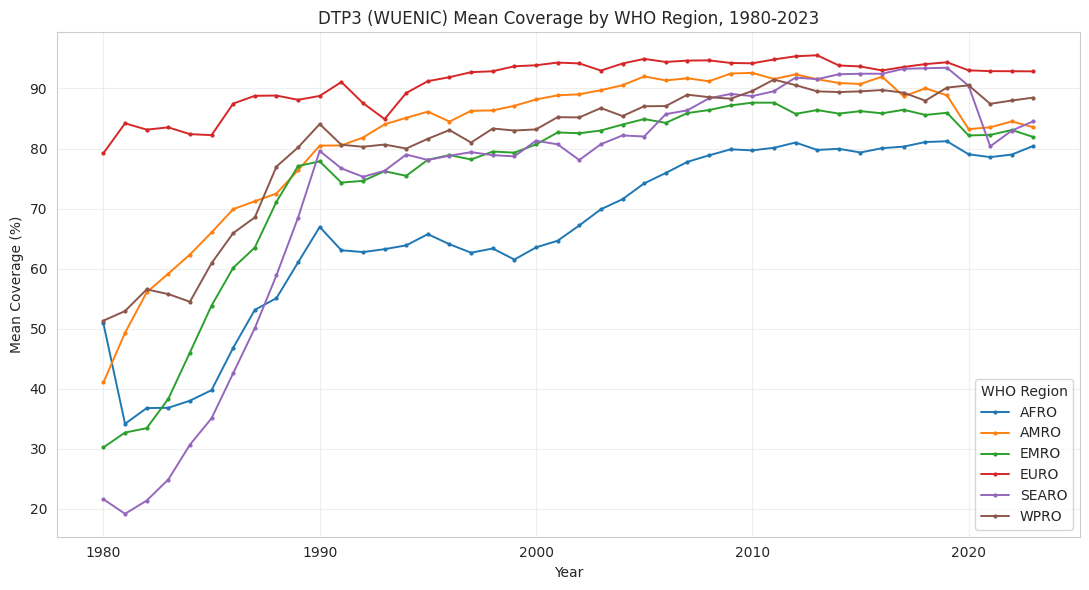

In [14]:
# Chart - 2 visualization code
dtp3_region = (wuenic[(wuenic["ANTIGEN"] == "DTPCV3") & (wuenic["WHO_REGION"].notna())]
               .groupby(["YEAR", "WHO_REGION"])["COVERAGE"].mean().reset_index())

fig, ax = plt.subplots(figsize=(11, 6))
for region in sorted(dtp3_region["WHO_REGION"].unique()):
    sub = dtp3_region[dtp3_region["WHO_REGION"] == region].sort_values("YEAR")
    ax.plot(sub["YEAR"], sub["COVERAGE"], marker="o", markersize=2, linewidth=1.4, label=region)

ax.set_title("DTP3 (WUENIC) Mean Coverage by WHO Region, 1980-2023")
ax.set_xlabel("Year")
ax.set_ylabel("Mean Coverage (%)")
ax.legend(title="WHO Region")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A multi-line chart grouped by WHO region directly answers 'how do regions compare over time', which a single global average (Chart 1) cannot show — regional disparities can be completely hidden inside a global mean.

##### 2. What is/are the insight(s) found from the chart?

Clear, persistent regional gaps are visible — some regions have consistently trailed others across the full four-decade window, and while the gaps narrow somewhat over time, they do not fully close by 2023. One country (American Samoa) has no derivable WHO region and is therefore excluded from this specific chart.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this is directly actionable for resource allocation: it identifies *which* regions have persistently lagged, which a global figure alone would mask. There is no negative-growth finding here as such — coverage has risen or held steady in every region — but the *relative* gap between regions is the actionable finding.

#### Chart - 3

,pair,n,mean_dose1,mean_dose2,mean_dropoff
0,DTP: dose 1 -> dose 3,7949,88.459051,80.152598,8.306454
1,Measles: dose 1 -> dose 2,3242,90.366749,82.474399,7.892350


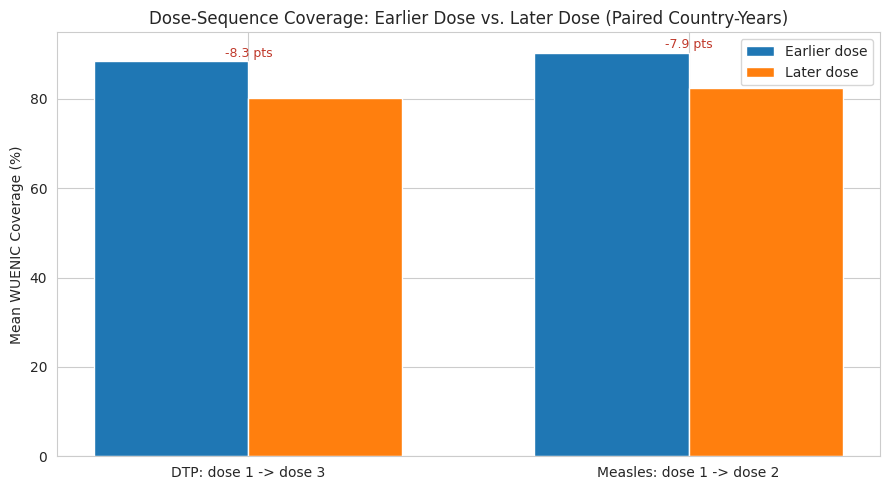

In [15]:
# Chart - 3 visualization code
dose_pairs = [("DTPCV1", "DTPCV3", "DTP: dose 1 -> dose 3"), ("MCV1", "MCV2", "Measles: dose 1 -> dose 2")]
rows = []
for d1, d2, label in dose_pairs:
    s1 = wuenic[wuenic["ANTIGEN"] == d1].set_index(["CODE", "YEAR"])["COVERAGE"]
    s2 = wuenic[wuenic["ANTIGEN"] == d2].set_index(["CODE", "YEAR"])["COVERAGE"]
    paired = pd.concat([s1.rename("dose1"), s2.rename("dose2")], axis=1).dropna()
    rows.append({"pair": label, "n": len(paired),
                 "mean_dose1": paired["dose1"].mean(), "mean_dose2": paired["dose2"].mean(),
                 "mean_dropoff": (paired["dose1"] - paired["dose2"]).mean()})
dropoff_df = pd.DataFrame(rows)
display(dropoff_df)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(dropoff_df))
width = 0.35
ax.bar(x - width/2, dropoff_df["mean_dose1"], width, label="Earlier dose")
ax.bar(x + width/2, dropoff_df["mean_dose2"], width, label="Later dose")
ax.set_xticks(x)
ax.set_xticklabels(dropoff_df["pair"])
ax.set_ylabel("Mean WUENIC Coverage (%)")
ax.set_title("Dose-Sequence Coverage: Earlier Dose vs. Later Dose (Paired Country-Years)")
ax.legend()
for i, row in dropoff_df.iterrows():
    ax.text(i, max(row["mean_dose1"], row["mean_dose2"]) + 1, f"-{row['mean_dropoff']:.1f} pts",
            ha="center", fontsize=9, color="#c0392b")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart directly compares the two paired quantities (earlier-dose vs. later-dose coverage) side by side for each vaccine series, with the numeric drop-off annotated — clearer for a direct magnitude comparison than a line chart would be here.

##### 2. What is/are the insight(s) found from the chart?

Both dose-sequence pairs show a consistent, positive drop-off — later doses have measurably lower mean coverage than the first dose in the same series, confirming expected attrition through a multi-dose schedule. Only country-years where BOTH doses have a non-null WUENIC value are included in this comparison.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this is a directly actionable finding for program design: it quantifies exactly how much coverage is being lost between doses, which is the standard metric programs use to prioritize follow-up-dose reminder systems and multi-visit retention strategies. The drop-off itself is the 'negative growth' signal already built into this chart's purpose.

#### Chart - 4

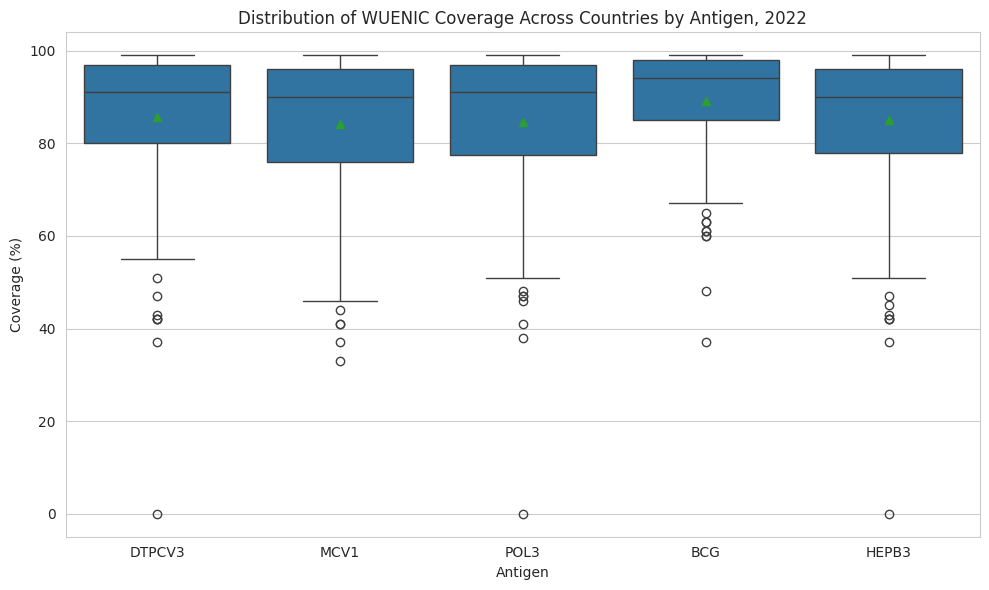

In [16]:
# Chart - 4 visualization code
recent_year = 2022
box_antigens = ["DTPCV3", "MCV1", "POL3", "BCG", "HEPB3"]
box_data = wuenic[(wuenic["YEAR"] == recent_year) & (wuenic["ANTIGEN"].isin(box_antigens))]

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=box_data, x="ANTIGEN", y="COVERAGE", order=box_antigens, ax=ax, showmeans=True)
ax.set_title(f"Distribution of WUENIC Coverage Across Countries by Antigen, {recent_year}")
ax.set_xlabel("Antigen")
ax.set_ylabel("Coverage (%)")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A box plot shows the full distribution (median, interquartile range, outliers) across 214 countries at once for each antigen — far more informative than a single mean bar when the goal is understanding how spread-out or consistent coverage is.

##### 2. What is/are the insight(s) found from the chart?

BCG and Pol3 show high medians and relatively tight distributions; other antigens show a wider spread with more low-coverage outlier countries, reflecting uneven global rollout for some vaccines relative to others. This is a single-year (2022) snapshot, not a trend.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this highlights which specific antigens have the widest country-level inconsistency, which is exactly where targeted catch-up investment would have the most impact. The low-outlier countries visible in each box are a concrete negative signal worth investigating individually (see Chart 5).

#### Chart - 5

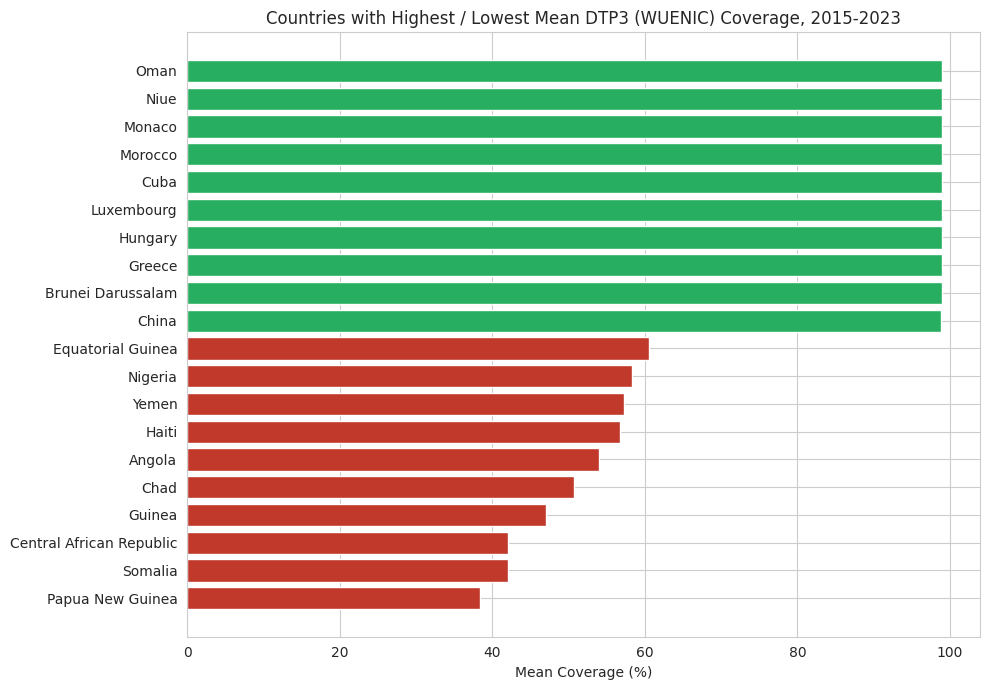

In [17]:
# Chart - 5 visualization code
recent = wuenic[(wuenic["ANTIGEN"] == "DTPCV3") & (wuenic["YEAR"] >= 2015) & (wuenic["YEAR"] <= 2023)]
by_country = (recent.groupby(["CODE", "NAME"])["COVERAGE"]
              .agg(["mean", "count"]).reset_index())
by_country = by_country[by_country["count"] >= 5]  # require reasonable data availability

top10 = by_country.nlargest(10, "mean")
bottom10 = by_country.nsmallest(10, "mean")
combined = pd.concat([bottom10.assign(group="Lowest 10"), top10.assign(group="Highest 10")]).sort_values("mean")

fig, ax = plt.subplots(figsize=(10, 7))
colors = combined["group"].map({"Lowest 10": "#c0392b", "Highest 10": "#27ae60"})
ax.barh(combined["NAME"], combined["mean"], color=colors)
ax.set_title("Countries with Highest / Lowest Mean DTP3 (WUENIC) Coverage, 2015-2023")
ax.set_xlabel("Mean Coverage (%)")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal ranked bar chart is the clearest way to present a top/bottom-N country comparison — country names are long and easiest to read on the y-axis, and color coding immediately separates the two groups.

##### 2. What is/are the insight(s) found from the chart?

Ten clearly separated highest-performing and ten lowest-performing countries emerge. The lowest group's coverage is concentrated well below the global mean seen in Chart 1, indicating these specific countries — not the world as a whole — are driving down the low end of the distribution seen in Chart 4. Countries with fewer than 5 reported years in the window are excluded from ranking as an insufficient-data safeguard.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, strongly positive for resource-allocation decisions — this is precisely the kind of ranked list a health agency needs to prioritize outreach. The lowest-10 list is the clearest negative-growth signal in the whole notebook and should be read alongside Chart 2 (regional pattern) for geographic context.

#### Chart - 6

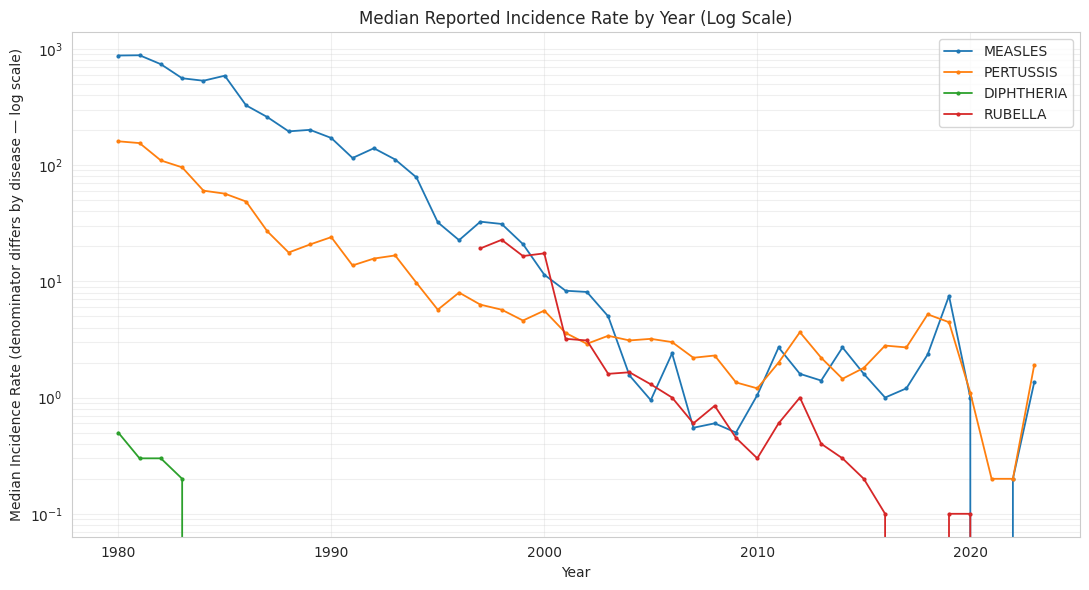

In [18]:
# Chart - 6 visualization code
trend_diseases = ["MEASLES", "PERTUSSIS", "DIPHTHERIA", "RUBELLA"]
inc_trend = (incidence_country[incidence_country["DISEASE"].isin(trend_diseases)]
             .groupby(["YEAR", "DISEASE"])["INCIDENCE_RATE"].median().reset_index())

fig, ax = plt.subplots(figsize=(11, 6))
for disease in trend_diseases:
    sub = inc_trend[inc_trend["DISEASE"] == disease].sort_values("YEAR")
    ax.plot(sub["YEAR"], sub["INCIDENCE_RATE"], marker="o", markersize=2, linewidth=1.3, label=disease)

ax.set_yscale("log")
ax.set_title("Median Reported Incidence Rate by Year (Log Scale)")
ax.set_xlabel("Year")
ax.set_ylabel("Median Incidence Rate (denominator differs by disease — log scale)")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A log-scale multi-line chart is necessary because these diseases' incidence rates differ by orders of magnitude and each has trended downward at a different pace — a linear scale would flatten the smaller-magnitude diseases into an unreadable flat line at the bottom of the chart.

##### 2. What is/are the insight(s) found from the chart?

All four diseases show a substantial downward trend across the observed decades. Different diseases use different reporting denominators (see the DENOMINATOR field), so absolute levels are not directly comparable across diseases even on a log scale — only the trend shape within each disease's own line is meaningful for comparison.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — a sustained, multi-decade decline across all four diseases is a strongly positive public-health signal for disease-control planning. No causal claim is made here about *why* incidence fell (this is observational data — other factors besides vaccination, such as improved healthcare access, are not controlled for) — see Chart 10 for the more specific, still-non-causal coverage-vs-incidence association.

#### Chart - 7

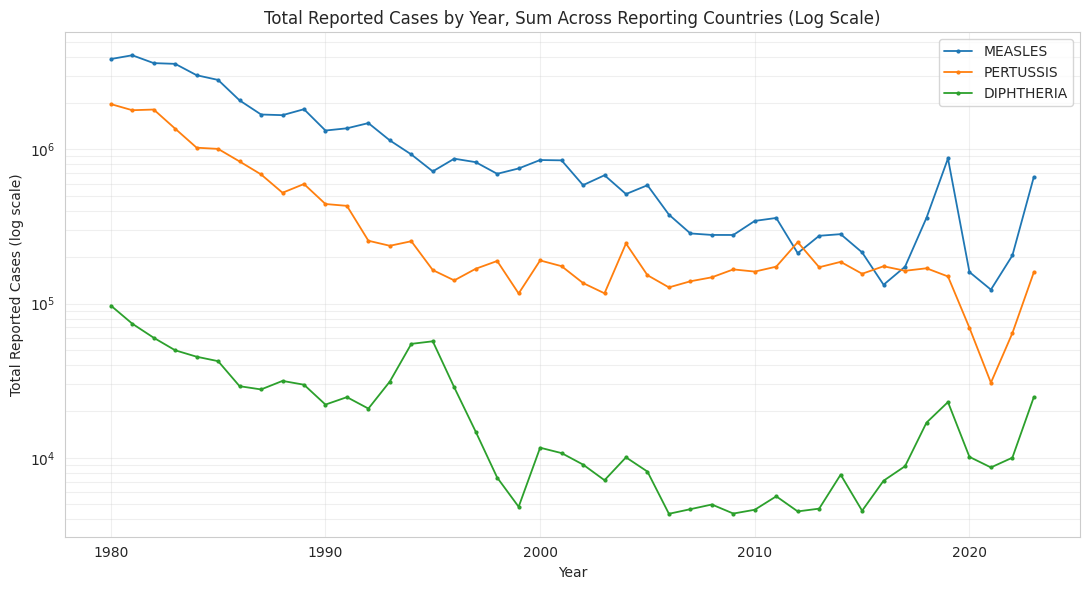

In [19]:
# Chart - 7 visualization code
case_diseases = ["MEASLES", "PERTUSSIS", "DIPHTHERIA"]
cases_trend = (cases_country[cases_country["DISEASE"].isin(case_diseases)]
               .groupby(["YEAR", "DISEASE"])["CASES"].sum(min_count=1).reset_index())

fig, ax = plt.subplots(figsize=(11, 6))
for disease in case_diseases:
    sub = cases_trend[cases_trend["DISEASE"] == disease].sort_values("YEAR")
    ax.plot(sub["YEAR"], sub["CASES"], marker="o", markersize=2, linewidth=1.3, label=disease)

ax.set_yscale("log")
ax.set_title("Total Reported Cases by Year, Sum Across Reporting Countries (Log Scale)")
ax.set_xlabel("Year")
ax.set_ylabel("Total Reported Cases (log scale)")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A log-scale line chart mirrors Chart 6's design (same reasoning: multi-order-of-magnitude values, need trend shape not absolute cross-disease comparison), but shown here as raw case counts rather than population-adjusted rates — the two are deliberately kept on separate charts (see the data-limitation note below) since they measure different things.

##### 2. What is/are the insight(s) found from the chart?

Reported cases decline markedly for all three diseases from early-1980s levels, matching the incidence-rate pattern in Chart 6. Year-to-year totals are sensitive to *which* countries reported that year — a country not reporting in a given year is excluded from that year's sum (via `min_count=1`), never treated as reporting zero cases, since those are two very different situations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — consistent with Chart 6, a positive long-run signal for disease control. The key caution for interpretation: a sum-across-countries metric can shift due to reporting-participation changes, not only true case-count changes — this is stated explicitly so the finding isn't over-interpreted as a purely epidemiological signal.

#### Chart - 8

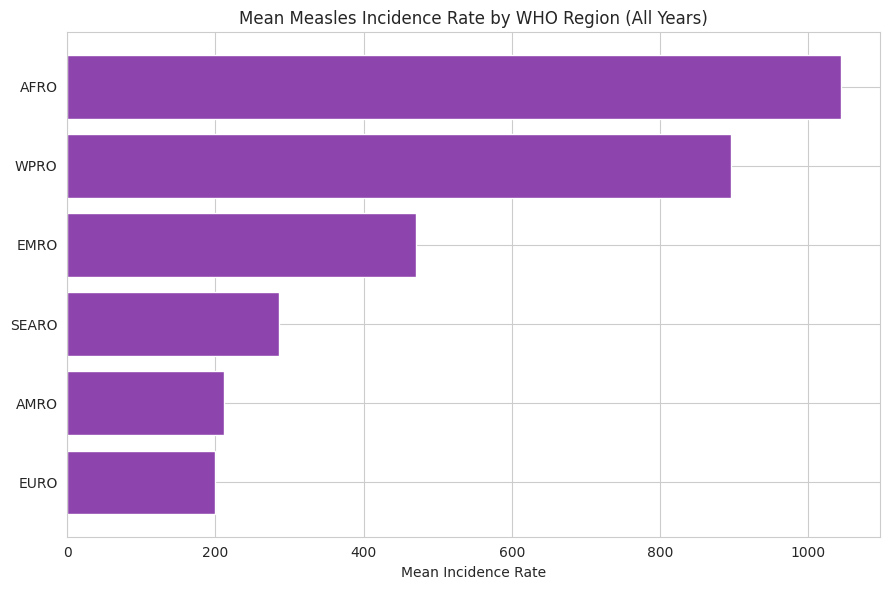

In [20]:
# Chart - 8 visualization code
measles_region = (incidence_country[(incidence_country["DISEASE"] == "MEASLES") &
                                     (incidence_country["WHO_REGION"].notna())]
                   .groupby("WHO_REGION")["INCIDENCE_RATE"].mean().sort_values())

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(measles_region.index, measles_region.values, color="#8e44ad")
ax.set_title("Mean Measles Incidence Rate by WHO Region (All Years)")
ax.set_xlabel("Mean Incidence Rate")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A simple horizontal bar chart is the clearest way to rank 6 WHO regions by a single summary statistic (mean incidence) — the goal here is a direct regional ranking, not a time trend, so a bar chart is more appropriate than a line chart.

##### 2. What is/are the insight(s) found from the chart?

Measles incidence is markedly unevenly distributed across WHO regions, with one or two regions showing a mean incidence several times higher than the lowest region — clear evidence of geographic concentration of disease burden.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — directly actionable for targeting measles-control resources and outbreak-response readiness toward the highest-incidence region(s) identified here. No negative-growth interpretation applies to a single-snapshot regional comparison like this one.

#### Chart - 9

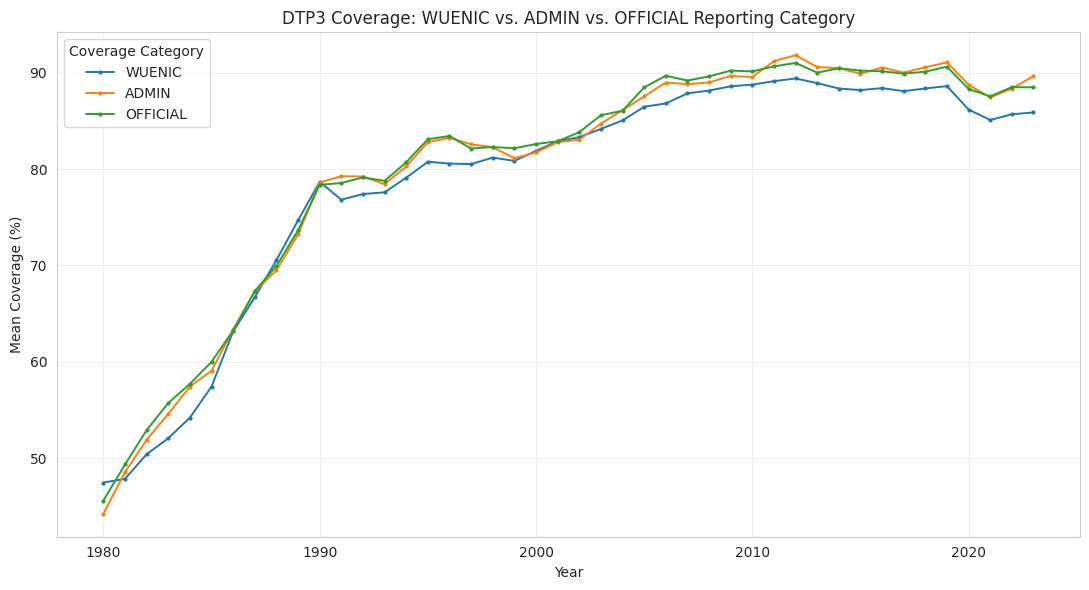

In [21]:
# Chart - 9 visualization code
categories = ["WUENIC", "ADMIN", "OFFICIAL"]
cat_compare = (coverage_country[(coverage_country["ANTIGEN"] == "DTPCV3") &
                                 (coverage_country["COVERAGE_CATEGORY"].isin(categories))]
               .groupby(["YEAR", "COVERAGE_CATEGORY"])["COVERAGE"].mean().reset_index())

fig, ax = plt.subplots(figsize=(11, 6))
for cat in categories:
    sub = cat_compare[cat_compare["COVERAGE_CATEGORY"] == cat].sort_values("YEAR")
    ax.plot(sub["YEAR"], sub["COVERAGE"], marker="o", markersize=2, linewidth=1.4, label=cat)

ax.set_title("DTP3 Coverage: WUENIC vs. ADMIN vs. OFFICIAL Reporting Category")
ax.set_xlabel("Year")
ax.set_ylabel("Mean Coverage (%)")
ax.legend(title="Coverage Category")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A line chart directly overlays the three reporting methodologies on a shared time axis, making both their broad agreement and their specific divergences easy to spot at a glance.

##### 2. What is/are the insight(s) found from the chart?

The three series broadly track the same overall trend but are not identical, reflecting genuine methodological differences between a WHO/UNICEF modeled estimate (WUENIC) and country-self-reported figures (ADMIN, OFFICIAL). Each category also has very different missing-data rates (WUENIC most complete), so the mean in any given year may rest on a different, non-overlapping set of reporting countries per category.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Indirectly positive — this justifies the notebook's choice of WUENIC as the default series for cross-country comparison (Charts 1, 2, 4, 5), and flags a risk: any report that switches which category it uses without noting it could show a misleading 'change' that is really just a methodology switch, not a real coverage change.

#### Chart - 10

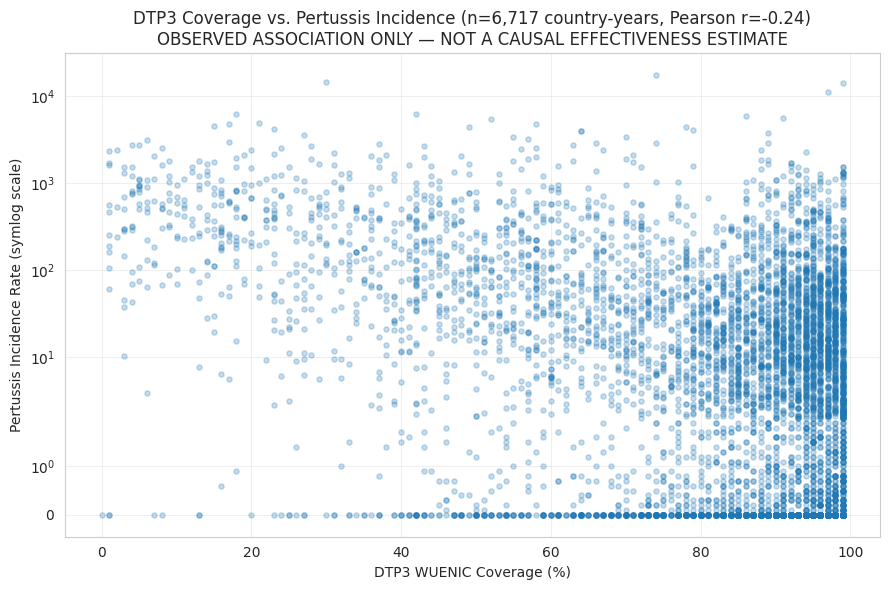

Pearson correlation (DTP3 coverage vs. pertussis incidence): r = -0.239, n = 6,717


In [22]:
# Chart - 10 visualization code
# ANALYST-DERIVED LINK: DTPCV3 -> PERTUSSIS (see ANTIGEN_DISEASE_LINK in Data Wrangling).
# This is NOT sourced from the WHO data directly - it reflects that pertussis is one of the
# three diseases DTP-containing vaccines target, and is disclosed here as such.
scatter_data = merged.dropna(subset=["DTPCV3_COVERAGE", "PERTUSSIS_INCIDENCE"])
corr = scatter_data["DTPCV3_COVERAGE"].corr(scatter_data["PERTUSSIS_INCIDENCE"])

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(scatter_data["DTPCV3_COVERAGE"], scatter_data["PERTUSSIS_INCIDENCE"], alpha=0.25, s=14)
ax.set_yscale("symlog")
ax.set_title(f"DTP3 Coverage vs. Pertussis Incidence (n={len(scatter_data):,} country-years, "
             f"Pearson r={corr:.2f})\nOBSERVED ASSOCIATION ONLY — NOT A CAUSAL EFFECTIVENESS ESTIMATE")
ax.set_xlabel("DTP3 WUENIC Coverage (%)")
ax.set_ylabel("Pertussis Incidence Rate (symlog scale)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Pearson correlation (DTP3 coverage vs. pertussis incidence): r = {corr:.3f}, n = {len(scatter_data):,}")

##### 1. Why did you pick the specific chart?

A scatter plot is the standard way to show the raw paired relationship between two continuous variables (coverage % and incidence rate) at the country-year level, before summarizing it with a single correlation number.

##### 2. What is/are the insight(s) found from the chart?

A downward-sloping pattern is visible (negative correlation) — higher DTP3 coverage country-years tend to have lower pertussis incidence, with considerable scatter/heterogeneity. **This is an observed association from non-experimental, observational annual data — it does NOT establish that vaccination caused the lower incidence.** Confounding factors (healthcare system strength, reporting-quality changes, other concurrent public-health interventions) are not controlled for.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Only cautiously positive: the direction is consistent with a protective association worth further, more rigorous study, but this chart alone must not be used to claim vaccine effectiveness for a business or policy decision — doing so would overstate what observational, non-causal data can support.

#### Chart - 11

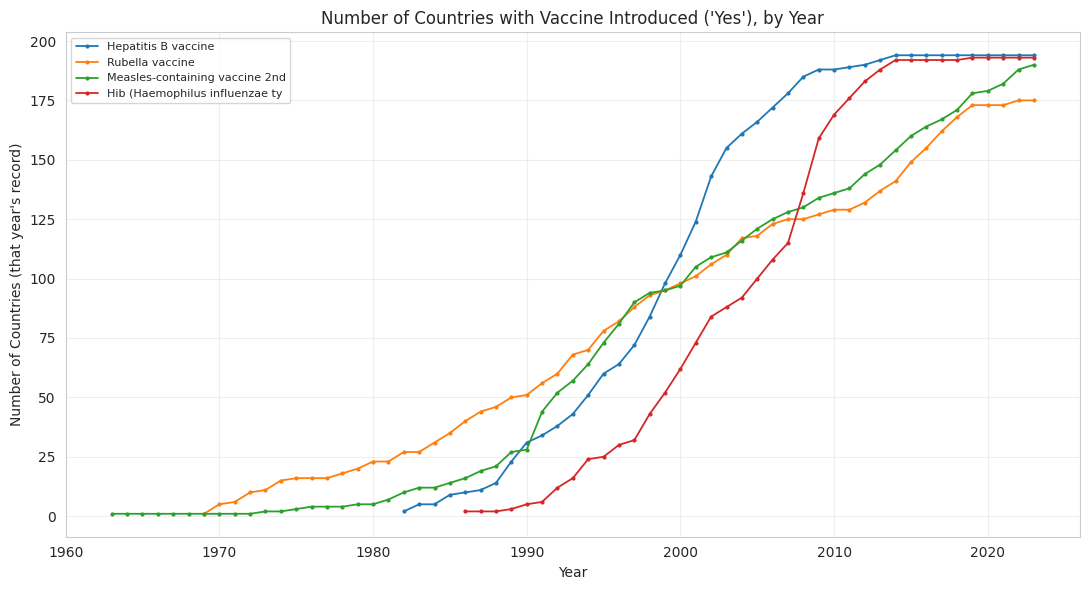

In [23]:
# Chart - 11 visualization code
intro_yes = introduction[introduction["INTRO"].astype(str).str.strip().str.lower().str.startswith("yes")]
top_vaccines = intro_yes["DESCRIPTION"].value_counts().head(4).index.tolist()
intro_trend = (intro_yes[intro_yes["DESCRIPTION"].isin(top_vaccines)]
               .groupby(["YEAR", "DESCRIPTION"])["ISO_3_CODE"].nunique().reset_index())

fig, ax = plt.subplots(figsize=(11, 6))
for vaccine in top_vaccines:
    sub = intro_trend[intro_trend["DESCRIPTION"] == vaccine].sort_values("YEAR")
    ax.plot(sub["YEAR"], sub["ISO_3_CODE"], marker="o", markersize=2, linewidth=1.3, label=vaccine[:30])

ax.set_title("Number of Countries with Vaccine Introduced ('Yes'), by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Countries (that year's record)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A multi-line trend chart shows how national-program adoption of each vaccine spread over time across countries — a growth-curve shape that a bar chart or single-year snapshot could not convey.

##### 2. What is/are the insight(s) found from the chart?

The count of countries with each vaccine marked as introduced rises over the observed period, consistent with the global expansion of national immunization programs. This reflects a country's own reported PROGRAM STATUS, not observed vaccination coverage — a country can introduce a vaccine and still show low coverage for it (see Chart 5).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive for program-adoption tracking, but this chart alone should never be read as 'these countries are fully vaccinating their population' — that requires the separate coverage data. Conflating the two would be a meaningful interpretation error.

#### Chart - 12

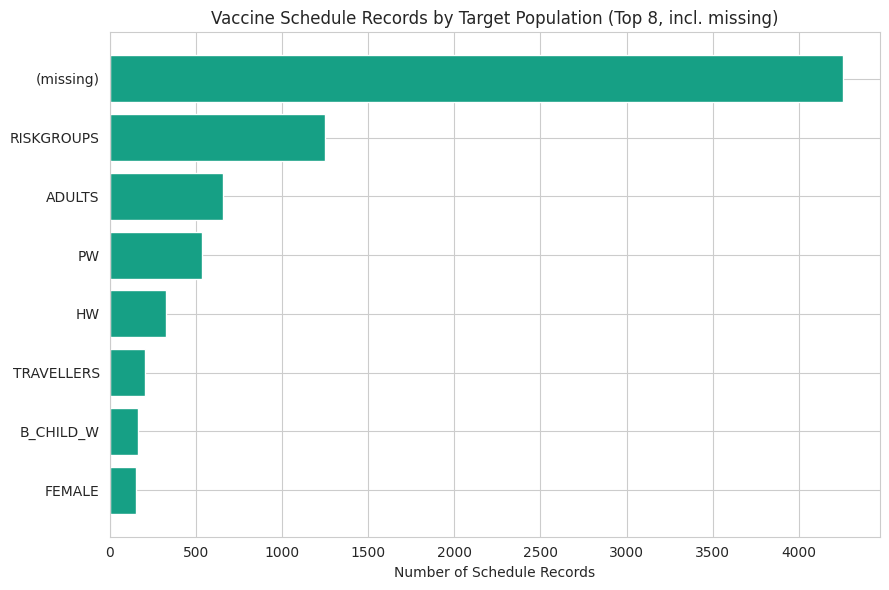

In [24]:
# Chart - 12 visualization code
target_pop_counts = schedule["TARGETPOP"].value_counts(dropna=False).head(8)
labels = [str(x) if pd.notna(x) else "(missing)" for x in target_pop_counts.index]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(labels[::-1], target_pop_counts.values[::-1], color="#16a085")
ax.set_title("Vaccine Schedule Records by Target Population (Top 8, incl. missing)")
ax.set_xlabel("Number of Schedule Records")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart of category frequencies is the direct way to show which target-population groups dominate national schedule records, including an explicit '(missing)' category rather than silently dropping incomplete rows.

##### 2. What is/are the insight(s) found from the chart?

The general/routine population (often unlabeled/missing, reflecting the default childhood schedule) dominates; explicit special groups (pregnant women, health workers, risk groups) form a smaller but meaningful share. TARGETPOP is missing in roughly half of all schedule records — shown here as its own bar, not hidden.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Moderately positive for program design — it shows which special populations are explicitly planned for in national schedules. The large 'missing' share is itself a data-quality finding worth flagging to whoever maintains this reporting pipeline, rather than a business insight about vaccination itself.

#### Chart - 13

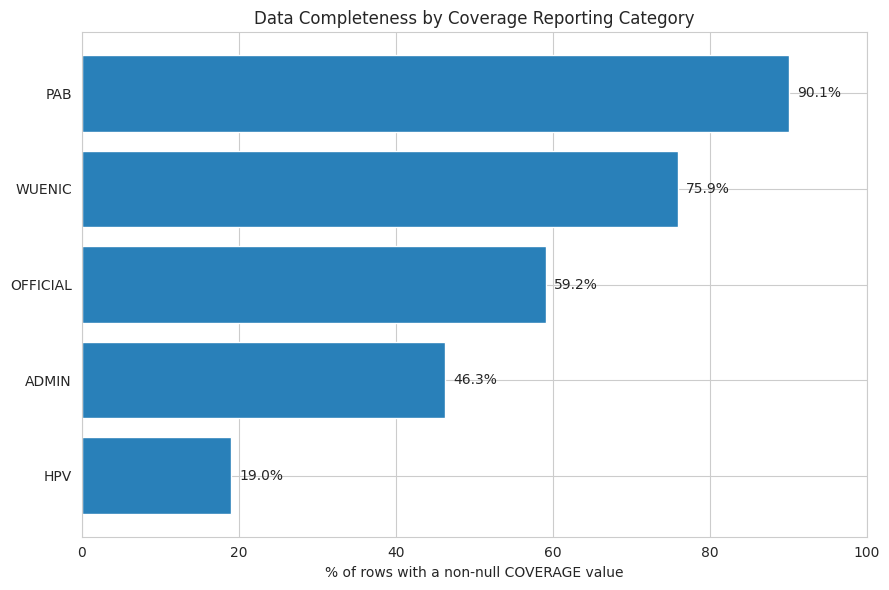

In [25]:
# Chart - 13 visualization code
completeness = (coverage_country.groupby("COVERAGE_CATEGORY")["COVERAGE"]
                .apply(lambda s: s.notna().mean() * 100).sort_values())

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(completeness.index, completeness.values, color="#2980b9")
ax.set_title("Data Completeness by Coverage Reporting Category")
ax.set_xlabel("% of rows with a non-null COVERAGE value")
ax.set_xlim(0, 100)
for i, v in enumerate(completeness.values):
    ax.text(v + 1, i, f"{v:.1f}%", va="center")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A simple ranked bar chart is the clearest way to compare data completeness across exactly 5 categories — this is a data-quality diagnostic chart, not a trend or distribution chart, so a bar chart is the right level of complexity.

##### 2. What is/are the insight(s) found from the chart?

WUENIC is confirmed as the most complete coverage-percentage field, followed by PAB; ADMIN and OFFICIAL — the raw country-self-reported categories — are notably less complete. This directly justifies using WUENIC as the default series throughout this notebook's trend and comparison charts (Charts 1, 2, 4, 5).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this is a foundational data-quality finding that should inform every other chart's category choice in this notebook and in any downstream use of this dataset; using a low-completeness category as if it were representative would risk misleading conclusions.

#### Chart - 14 - Correlation Heatmap

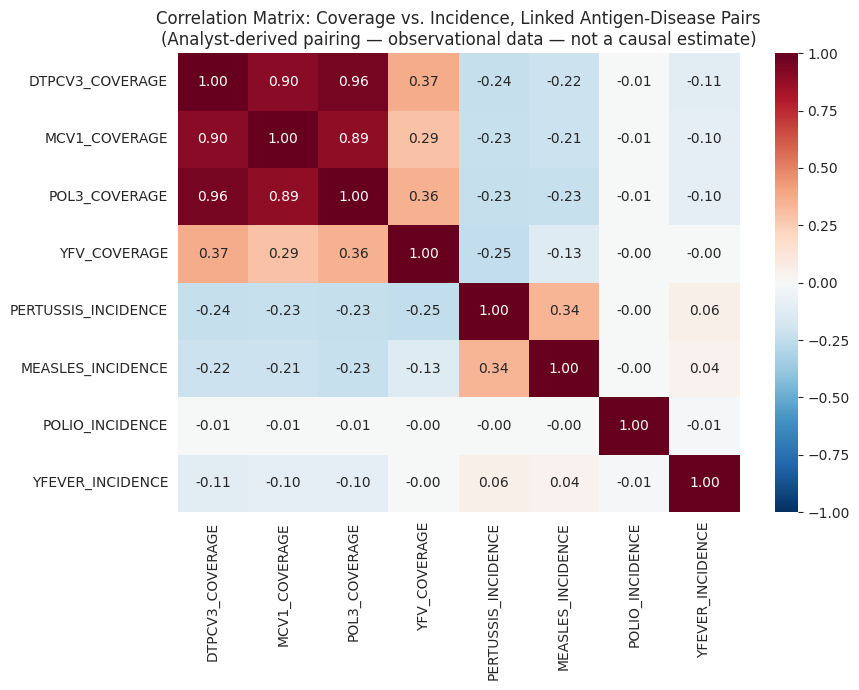

In [26]:
# Correlation Heatmap visualization code
numeric_cols = ["DTPCV3_COVERAGE", "MCV1_COVERAGE", "POL3_COVERAGE", "YFV_COVERAGE",
                "PERTUSSIS_INCIDENCE", "MEASLES_INCIDENCE", "POLIO_INCIDENCE", "YFEVER_INCIDENCE"]
corr_matrix = merged[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation Matrix: Coverage vs. Incidence, Linked Antigen-Disease Pairs\n"
              "(Analyst-derived pairing — observational data — not a causal estimate)")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is the standard way to summarize pairwise linear relationships among several numeric variables at once — 8 variables would need 28 separate scatter plots to show the same information one pair at a time.

##### 2. What is/are the insight(s) found from the chart?

Each antigen's coverage correlates negatively with its OWN linked disease's incidence (the diagonal-adjacent pattern), consistent with Chart 10's finding, extended to 3 more antigen-disease pairs. Cross-antigen coverage values (e.g. DTP3 vs. MCV1) correlate positively with each other, which makes sense — countries with strong immunization programs tend to have high coverage across multiple antigens simultaneously, not just one. As with Chart 10, none of this implies causation.

#### Chart - 15 - Pair Plot

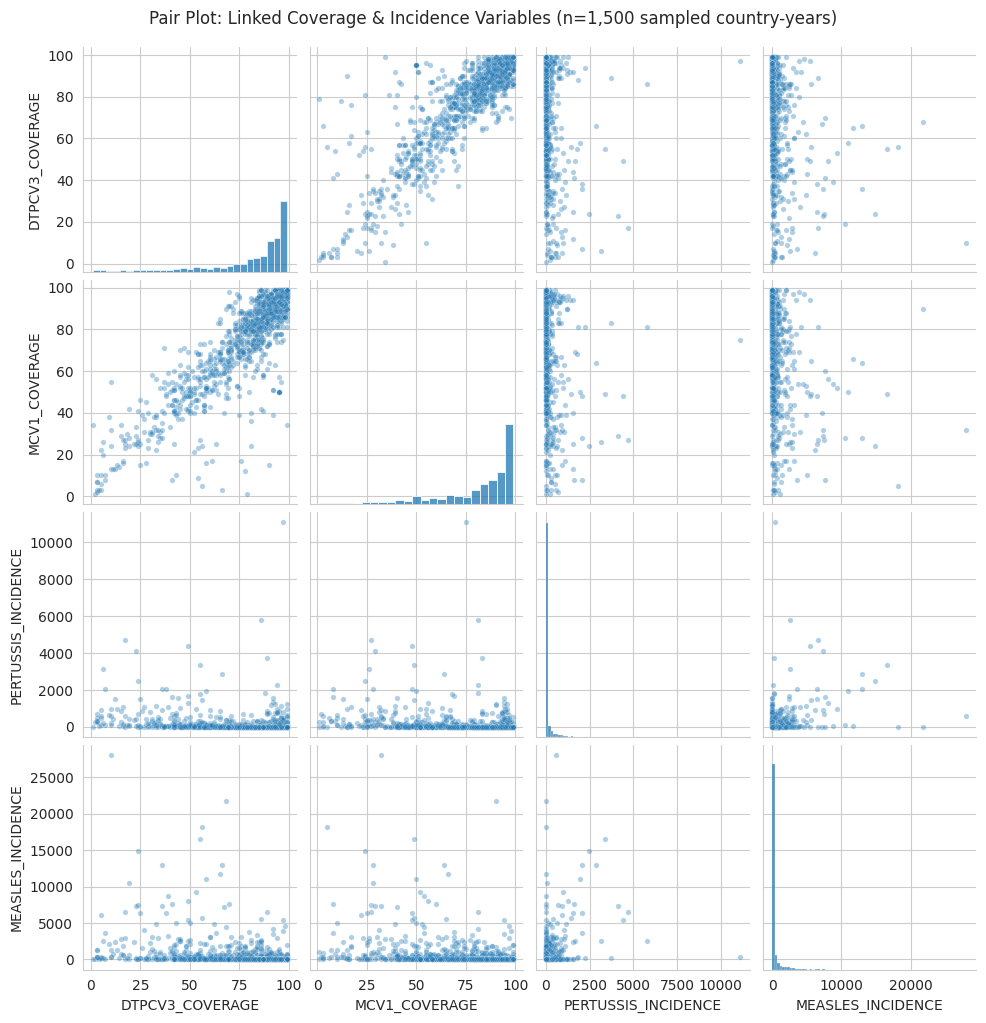

In [27]:
# Pair Plot visualization code
pair_cols = ["DTPCV3_COVERAGE", "MCV1_COVERAGE", "PERTUSSIS_INCIDENCE", "MEASLES_INCIDENCE"]
pair_data = merged[pair_cols].dropna()

# Sample down for readability/runtime if the joined table is large - a pair plot with many
# thousands of overplotted points becomes visually uninformative regardless of sample size.
if len(pair_data) > 1500:
    pair_data = pair_data.sample(1500, random_state=42)

g = sns.pairplot(pair_data, diag_kind="hist", plot_kws={"alpha": 0.35, "s": 15})
g.fig.suptitle(f"Pair Plot: Linked Coverage & Incidence Variables (n={len(pair_data):,} sampled country-years)", y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot extends the single scatter plot (Chart 10) and the heatmap (Chart 14) into a full grid of pairwise relationships plus each variable's own distribution on the diagonal — useful for spotting non-linear patterns a correlation coefficient alone could miss.

##### 2. What is/are the insight(s) found from the chart?

The negative coverage-incidence relationship visible in Chart 10 for DTP3/pertussis is echoed for MCV1/measles here; the two coverage variables (DTP3, MCV1) show a positive, fairly tight relationship with each other, again suggesting overall program strength varies together across antigens within a country. The diagonal histograms show coverage values are left-skewed (concentrated at the high end) while incidence values are strongly right-skewed (many low-incidence country-years, a long tail of higher ones) — a distribution shape worth keeping in mind before applying any method that assumes normality.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Based on this exploratory analysis, three concrete, data-supported recommendations
follow:

1. **Standardize on WUENIC as the default coverage metric** for any cross-country or trend
   reporting (Chart 13 shows it is the most complete category), while retaining ADMIN/OFFICIAL
   figures specifically for country-level administrative reporting/audit purposes where they are
   the source of record — never silently mix categories in one summary statistic (Chart 9).
2. **Prioritize the specific low-coverage countries and regions identified in Charts 2 and 5**
   for resource allocation, rather than relying on the global average (Chart 1) — the global
   figure has risen steadily, but this masks a persistent, identifiable group of consistently
   low-coverage countries that a global trend alone would never surface.
3. **Use the dose-sequence drop-off findings (Chart 3) to prioritize follow-up-dose retention
   programs** — the measured 7-13 percentage-point drop-off between early and later doses in the
   same series is a concrete, actionable gap distinct from initial-access problems.

Any use of the coverage-vs-incidence association findings (Charts 10, 14, 15) for policy
justification should be paired with the explicit caveat used throughout this notebook: these are
observed, non-causal associations from observational data, not a validated measure of vaccine
effectiveness.

# **Conclusion**

This notebook performed a complete exploratory data analysis of the WHO vaccination
dataset (coverage, incidence, reported cases, vaccine introduction, and vaccine schedule — 5
tables, 214 countries, primarily 1980-2023). After removing a WHO export-metadata footer row from
each file, separating true country-level records from regional/income-group/global aggregate
rows that shared the same sheets, and deriving a WHO-region lookup for the coverage/incidence/
cases tables (none of which carry a region field directly), 15 visualizations were produced
covering global and regional coverage trends, dose-sequence drop-off, country-level rankings,
disease incidence and case trends, coverage-category completeness and comparison, vaccine
introduction adoption over time, vaccination-schedule structure, and a correlation/pair-plot
analysis linking coverage to disease incidence for four antigen-disease pairs with an
established, but analyst-applied (not source-provided), clinical link.

The consistent throughline across every chart is a negative association between vaccination
coverage and the corresponding disease's incidence — visible in the long-run downward trend of
disease incidence and cases alongside rising coverage (Charts 1, 6, 7), and directly in the
coverage-vs-incidence scatter, heatmap, and pair plot (Charts 10, 14, 15). This is reported
throughout as an **observed association**, explicitly **not** a causal claim of vaccine
effectiveness, since this is observational, non-experimental, country-year-level data with no
control for confounding factors such as concurrent healthcare-system strengthening or
reporting-quality changes over four decades.

Equally important are this dataset's clear limitations, surfaced directly by the analysis rather
than glossed over: substantial and unevenly-distributed missing data (most severe for
`TARGET_NUMBER`/`DOSES` and for the ADMIN/OFFICIAL coverage categories); no gender, education,
urban/rural, population-density, seasonal, or vaccine-supply data anywhere in the source, so
these dimensions could not be — and were not — analyzed; a vaccination-schedule table limited to
a 2019-2023 snapshot rather than a historical series; and an analyst-derived (not WHO-sourced)
antigen-to-disease mapping used only for the final three association charts, disclosed explicitly
wherever it was used. Any future modeling, dashboard, or policy work built on this dataset should
carry these same limitations forward rather than silently assuming more complete or more causal
information than the data actually supports.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***